In [3]:
# Imports
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 6)

### Data

In [ ]:
flow_path = Path("./TrafficProject/results/task3_flow_timeseries_5sec.csv")

if not flow_path.exists():
    flow_path = Path("./TrafficProject/results/task3_flow_timeseries.csv")

traffic = pd.read_csv(flow_path)

required_columns = ["north_in", "south_in", "east_in", "west_in"]
missing_columns = [column for column in required_columns if column not in traffic.columns]
if missing_columns:
    raise ValueError(f"Missing required Task 3 columns: {missing_columns}")

traffic.head(10)

,time_bin_5sec,west_in,east_in,north_in,south_in,total_flow
0,0,38,33,48,38,157
1,1,105,107,70,28,310
2,2,54,94,34,35,217
3,3,34,118,71,30,253
4,4,127,137,51,31,346
5,5,153,121,28,24,326
6,6,74,145,53,16,288
7,7,83,124,51,33,291
8,8,122,119,20,15,276
9,9,91,86,64,30,271


In [6]:
direction_summary = pd.DataFrame({
    "direction": ["north", "south", "east", "west"],
    "avg_flow": [
        traffic["north_in"].mean(),
        traffic["south_in"].mean(),
        traffic["east_in"].mean(),
        traffic["west_in"].mean(),
    ],
    "max_flow": [
        traffic["north_in"].max(),
        traffic["south_in"].max(),
        traffic["east_in"].max(),
        traffic["west_in"].max(),
    ],
})

direction_summary["flow_share"] = direction_summary["avg_flow"] / direction_summary["avg_flow"].sum()
direction_summary

,direction,avg_flow,max_flow,flow_share
0,north,35.000000,100,0.153014
1,south,16.902439,59,0.073894
2,east,94.957317,198,0.415136
3,west,81.878049,182,0.357956


### Traffic Graph

- Nodes represent intersections or upstream road sections.
- Edges represent roads connecting those locations.
- Node features describe local traffic pressure and intersection type.
- Edge features describe road length, lane count, estimated flow, and congestion.

In [12]:
node_data = pd.DataFrame([
    {"node_id": "N", "label": "North upstream", "node_type": "upstream", "x": 0, "y": 1},
    {"node_id": "S", "label": "South upstream", "node_type": "upstream", "x": 0, "y": -1},
    {"node_id": "E", "label": "East upstream", "node_type": "upstream", "x": 1, "y": 0},
    {"node_id": "W", "label": "West upstream", "node_type": "upstream", "x": -1, "y": 0},
    {"node_id": "C", "label": "Chosen junction", "node_type": "signalized", "x": 0, "y": 0},
])

# Estimated map/road features. These can be replaced with exact OSM/Google Maps values.
road_features = {
    "north": {"from": "N", "to": "C", "length_m": 95, "lanes": 2, "speed_kmh": 40},
    "south": {"from": "S", "to": "C", "length_m": 90, "lanes": 1, "speed_kmh": 40},
    "east": {"from": "E", "to": "C", "length_m": 120, "lanes": 2, "speed_kmh": 40},
    "west": {"from": "W", "to": "C", "length_m": 115, "lanes": 2, "speed_kmh": 40},
}

edge_rows = []
for _, row in direction_summary.iterrows():
    direction = row["direction"]
    road = road_features[direction]
    travel_time_seconds = road["length_m"] / (road["speed_kmh"] * 1000 / 3600)
    capacity_proxy = road["lanes"] * road["speed_kmh"]
    congestion_index = row["avg_flow"] / capacity_proxy

    edge_rows.append({
        "source": road["from"],
        "target": road["to"],
        "direction": direction,
        "length_m": road["length_m"],
        "lanes": road["lanes"],
        "speed_kmh": road["speed_kmh"],
        "free_flow_time_s": travel_time_seconds,
        "avg_flow": row["avg_flow"],
        "max_flow": row["max_flow"],
        "flow_share": row["flow_share"],
        "congestion_index": congestion_index,
    })

    # Add a return road with smaller flow so the graph is bidirectional.
    edge_rows.append({
        "source": road["to"],
        "target": road["from"],
        "direction": direction + "_out",
        "length_m": road["length_m"],
        "lanes": road["lanes"],
        "speed_kmh": road["speed_kmh"],
        "free_flow_time_s": travel_time_seconds,
        "avg_flow": row["avg_flow"] * 0.8,
        "max_flow": row["max_flow"] * 0.8,
        "flow_share": row["flow_share"],
        "congestion_index": congestion_index * 0.8,
    })

edge_data = pd.DataFrame(edge_rows)

In [10]:
node_data.head(5)

,node_id,label,node_type,x,y
0,N,North upstream,upstream,0,1
1,S,South upstream,upstream,0,-1
2,E,East upstream,upstream,1,0
3,W,West upstream,upstream,-1,0
4,C,Chosen junction,signalized,0,0


In [11]:
edge_data.head(5)

,source,target,direction,length_m,lanes,speed_kmh,free_flow_time_s,avg_flow,max_flow,flow_share,congestion_index
0,N,C,north,95,2,40,8.55,35.000000,100.0,0.153014,0.437500
1,C,N,north_out,95,2,40,8.55,28.000000,80.0,0.153014,0.350000
2,S,C,south,90,1,40,8.10,16.902439,59.0,0.073894,0.422561
3,C,S,south_out,90,1,40,8.10,13.521951,47.2,0.073894,0.338049
4,E,C,east,120,2,40,10.80,94.957317,198.0,0.415136,1.186966


In [15]:
G = nx.DiGraph()

for _, row in node_data.iterrows():
    G.add_node(
        row["node_id"],
        label=row["label"],
        node_type=row["node_type"],
        pos=(row["x"], row["y"]),
    )

for _, row in edge_data.iterrows():
    G.add_edge(
        row["source"],
        row["target"],
        direction=row["direction"],
        length_m=row["length_m"],
        lanes=row["lanes"],
        speed_kmh=row["speed_kmh"],
        avg_flow=row["avg_flow"],
        congestion_index=row["congestion_index"],
    )

In [16]:
def print_graph_info(graph):
    print(f"Number of nodes: {graph.number_of_nodes()}")
    print(f"Number of edges: {graph.number_of_edges()}")
    print(f"Directed graph: {nx.is_directed(graph)}")
    print("\nNode attributes example:")
    for node, data in graph.nodes(data=True):
        print(f"Node {node}: {data}")
        break
    print("\nEdge attributes example:")
    for u, v, data in graph.edges(data=True):
        print(f"Edge from {u} to {v}: {data}")
        break

print_graph_info(G)

Number of nodes: 5
Number of edges: 8
Directed graph: True

Node attributes example:
Node N: {'label': 'North upstream', 'node_type': 'upstream', 'pos': (0, 1)}

Edge attributes example:
Edge from N to C: {'direction': 'north', 'length_m': 95, 'lanes': 2, 'speed_kmh': 40, 'avg_flow': 35.0, 'congestion_index': 0.4375}


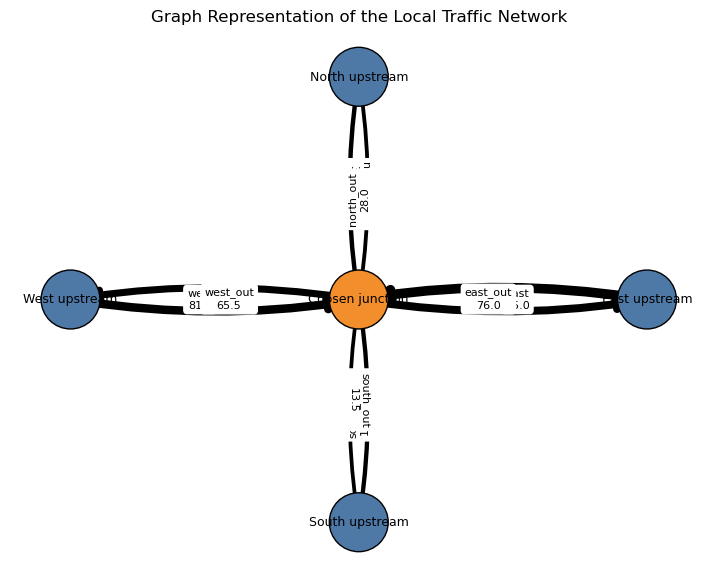

In [17]:
pos = nx.get_node_attributes(G, "pos")
node_colors = ["#f28e2b" if G.nodes[node]["node_type"] == "signalized" else "#4e79a7" for node in G.nodes]
edge_widths = [1 + 5 * G.edges[edge]["congestion_index"] for edge in G.edges]
edge_labels = {(u, v): f"{data['direction']}\n{data['avg_flow']:.1f}" for u, v, data in G.edges(data=True)}

plt.figure(figsize=(9, 7))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1800, edgecolors="black")
nx.draw_networkx_labels(G, pos, labels=nx.get_node_attributes(G, "label"), font_size=9)
nx.draw_networkx_edges(G, pos, width=edge_widths, arrows=True, arrowsize=18, connectionstyle="arc3,rad=0.08")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, label_pos=0.55)
plt.title("Graph Representation of the Local Traffic Network")
plt.axis("off")
plt.show()

### Node and Edge Features

In [18]:
node_feature_rows = []
for node in G.nodes:
    incoming_flow = sum(data["avg_flow"] for _, _, data in G.in_edges(node, data=True))
    outgoing_flow = sum(data["avg_flow"] for _, _, data in G.out_edges(node, data=True))
    node_feature_rows.append({
        "node_id": node,
        "is_signalized": int(G.nodes[node]["node_type"] == "signalized"),
        "in_degree": G.in_degree(node),
        "out_degree": G.out_degree(node),
        "incoming_flow": incoming_flow,
        "outgoing_flow": outgoing_flow,
        "total_flow": incoming_flow + outgoing_flow,
    })

node_features = pd.DataFrame(node_feature_rows)
node_features.head(5)

,node_id,is_signalized,in_degree,out_degree,incoming_flow,outgoing_flow,total_flow
0,N,0,1,1,28.000000,35.000000,63.000000
1,S,0,1,1,13.521951,16.902439,30.424390
2,E,0,1,1,75.965854,94.957317,170.923171
3,W,0,1,1,65.502439,81.878049,147.380488
4,C,1,4,4,228.737805,182.990244,411.728049


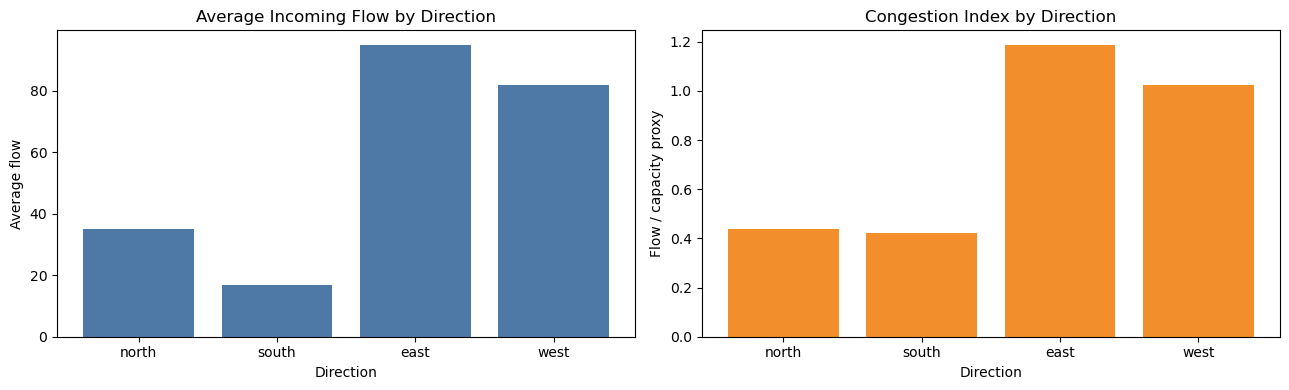

In [20]:
incoming_edges = edge_data[edge_data["target"] == "C"].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(incoming_edges["direction"], incoming_edges["avg_flow"], color="#4e79a7")
axes[0].set_title("Average Incoming Flow by Direction")
axes[0].set_xlabel("Direction")
axes[0].set_ylabel("Average flow")

axes[1].bar(incoming_edges["direction"], incoming_edges["congestion_index"], color="#f28e2b")
axes[1].set_title("Congestion Index by Direction")
axes[1].set_xlabel("Direction")
axes[1].set_ylabel("Flow / capacity proxy")

plt.tight_layout()
plt.show()

In [21]:
try:
    import torch
    from torch_geometric.data import Data

    node_order = list(G.nodes)
    node_to_index = {node: index for index, node in enumerate(node_order)}

    x = torch.tensor(
        node_features.set_index("node_id").loc[node_order, [
            "is_signalized",
            "in_degree",
            "out_degree",
            "incoming_flow",
            "outgoing_flow",
            "total_flow",
        ]].values,
        dtype=torch.float,
    )

    edge_index = torch.tensor(
        [[node_to_index[u], node_to_index[v]] for u, v in G.edges],
        dtype=torch.long,
    ).t().contiguous()

    edge_attr = torch.tensor(
        edge_data[["length_m", "lanes", "speed_kmh", "free_flow_time_s", "avg_flow", "congestion_index"]].values,
        dtype=torch.float,
    )

    traffic_graph_data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    print(traffic_graph_data)
    print(f"x shape: {traffic_graph_data.x.shape}")
    print(f"edge_index shape: {traffic_graph_data.edge_index.shape}")
    print(f"edge_attr shape: {traffic_graph_data.edge_attr.shape}")
except ImportError as error:
    print("PyTorch Geometric is not installed in this environment.")
    print("The NetworkX graph and feature tables above are still enough for the conceptual Part 4 task.")
    print(error)

Data(x=[5, 6], edge_index=[2, 8], edge_attr=[8, 6])
x shape: torch.Size([5, 6])
edge_index shape: torch.Size([2, 8])
edge_attr shape: torch.Size([8, 6])


### How a GNN Could Model This Traffic Network

A Graph Neural Network could be used to learn how traffic conditions at one intersection affect nearby intersections. Each node would contain features such as current queue length, incoming flow, outgoing flow, number of lanes, signal type, and recent average delay. Each edge would contain features such as road length, number of lanes, speed limit, travel time, and estimated traffic flow.

During message passing, each intersection would receive information from neighboring intersections through the connecting roads. For example, if the east upstream road has high traffic flow and a high congestion index, that information would be passed to the central junction node. The model could then learn that congestion on this approach increases future waiting time at the selected intersection.

A GNN for this task could predict several useful outputs:

- future traffic flow at each intersection,
- expected queue length for each approach,
- congestion level of each road segment,
- travel time between intersections,
- risk of congestion spreading from one intersection to another,
- recommended signal timing adjustments.

This would be useful because traffic is spatially dependent. A normal model that looks only at one intersection may miss congestion that is forming nearby. A GNN can combine local features with information from connected roads, making it more suitable for traffic networks.

### Conclusion of GNN usage

A Graph Neural Network would be useful for global predictions. With traffic data it actually learns 